In [2]:
!pip install torch torchvision

   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.5/113.8 MB 402.7 kB/s eta 0:04:42
   ---------------------------------------- 0.8/113.8 MB 546.4 kB/s eta 0:03:27
   ---------------------------------------- 1.0/113.8 MB 625.5 kB/s eta 0:03:01
   ---------------------------------------- 1.0/113.8 MB 625.5 kB/s eta 0:03:01
   ---------------------------------------- 1.3/113.8 MB 680.2 kB/s eta 0:02:46
    --------------------------------------- 1.6/113.8 MB 719.1 kB/s eta 0:02:37
    -------------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [4]:
#Data Preprocessing

# Transformations for MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load training dataset
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Load testing dataset
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Create data loaders
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

100.0%
100.0%
100.0%
100.0%


Training samples: 60000
Testing samples: 10000


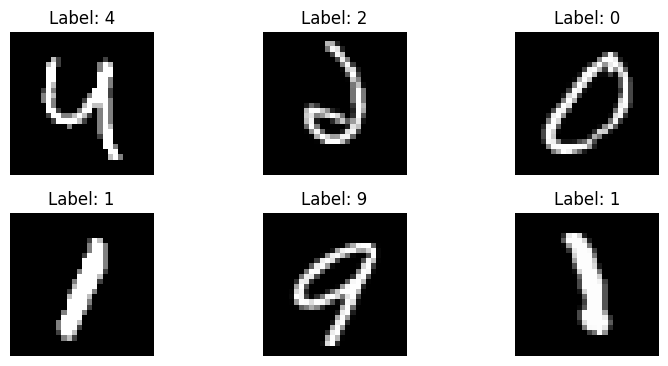

In [5]:
#Visualize Sample Images

# Display some sample images
examples = enumerate(train_loader)
batch_idx, (example_data, example_targets) = next(examples)

fig = plt.figure(figsize=(8,4))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.tight_layout()
    plt.imshow(example_data[i][0], cmap='gray')
    plt.title("Label: {}".format(example_targets[i].item()))
    plt.axis('off')

plt.show()

In [6]:
#Improved Neural Network Architecture

class ImprovedMNISTModel(nn.Module):

    def __init__(self):
        super(ImprovedMNISTModel, self).__init__()

        self.model = nn.Sequential(

            nn.Flatten(),

            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)


model = ImprovedMNISTModel()

print(model)

ImprovedMNISTModel(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=128, out_features=64, bias=True)
    (8): ReLU()
    (9): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [7]:
#Loss Function and Optimizer

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
#Training the Model

epochs = 5

for epoch in range(epochs):

    running_loss = 0.0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/5, Loss: 0.4826
Epoch 2/5, Loss: 0.2454
Epoch 3/5, Loss: 0.2061
Epoch 4/5, Loss: 0.1839
Epoch 5/5, Loss: 0.1685


In [9]:
#Model Evaluation

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print("Test Accuracy:", accuracy, "%")

Test Accuracy: 94.97 %


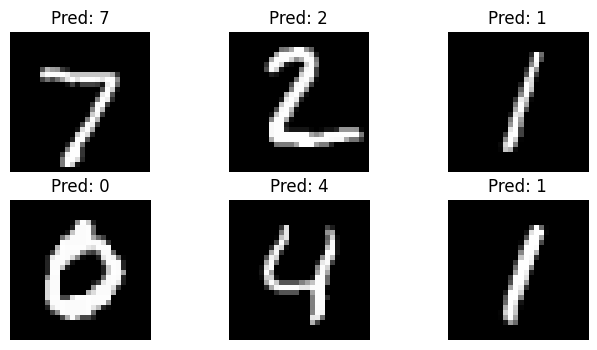

In [10]:
#Test Predictions Visualization

dataiter = iter(test_loader)
images, labels = next(dataiter)

outputs = model(images)
_, predictions = torch.max(outputs, 1)

fig = plt.figure(figsize=(8,4))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title(f"Pred: {predictions[i].item()}")
    plt.axis('off')

plt.show()